In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'benchmark').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.diffusion.calibration.thresholds import (
    DEFAULT_POSTERIOR_MMD_QUANTILE,
    DEFAULT_SIGNED_ERROR_COVERAGE,
)
from benchmark.examples.diffusion.config import BASE_DIR, FIGURE_DIR, TrainingConfig
from benchmark.examples.diffusion.results.summary_dimension_comparison import (
    DIAGNOSTICS,
    LOSS_VARIANTS,
    MODEL_SETS,
    NO_MMD_SUMMARY_SPECS,
    VISUALIZATION_SUMMARY_LABELS,
    generate_calibrated_gold_pmp_lowess_grid,
    generate_log10_logml_diagnostic_loess_grid,
    generate_pmp_diagnostic_loess_grid,
    generate_posterior_mmd_diagnostic_loess_grid,
    generate_s4d_diagnostic_gold_pmp_grid,
    run_calibrated_comparison_pipeline,
)

INFO:bayesflow:Using backend 'tensorflow'


In [ ]:
RERUN_SUFFIX = 'noMMD_rerun1'
RERUN_VARIANT = 'without_mmd_rerun1'
RERUN_SUMMARY_SPECS = tuple(
    (
        label,
        TrainingConfig(
            summary_multiplier=config.summary_multiplier,
            summary_base_distribution=None,
            run_suffix=RERUN_SUFFIX,
        ),
    )
    for label, config in NO_MMD_SUMMARY_SPECS
)
LOSS_VARIANTS[RERUN_VARIANT] = (
    'Without MMD loss (rerun1)',
    RERUN_SUMMARY_SPECS,
)

OUTPUT_ROOT = FIGURE_DIR / 's4d_diagnostic_comparison_rerun1'
CALIBRATED_OUTPUT_ROOT = FIGURE_DIR / 'summary_diagnostics_noMMD_rerun1_calibrated_thresholds'
OVERLAY_OUTPUT_ROOT = FIGURE_DIR / 'diagnostic_overlays_calibrated_noMMD_rerun1'
THRESHOLD_PATH = BASE_DIR / 'calibration_outputs_rerun1' / 'thresholds.csv'

# Current plotting contract. S=6D remains available in the tables but is not plotted.
XSCALE = 'symlog'
YSCALE = {'posterior_mmd': 'linear', 'logml': 'symlog', 'pmp': 'linear'}
NORMALIZE_METRICS = False

THRESHOLD_CONTRACT = {
    'posterior_mmd': (0.95, 0.00, 0.95),
    'signed_logml_error': (0.90, 0.05, 0.95),
    'signed_pmp_error': (0.90, 0.05, 0.95),
}
PLOT_SUMMARIES = ('S=D', 'S=2D', 'S=4D')


def validate_threshold_contract(path):
    table = pd.read_csv(path)
    required = {
        'metric', 'quantile', 'lower_quantile', 'upper_quantile',
        'summary_multiplier',
    }
    missing = sorted(required.difference(table.columns))
    if missing:
        raise ValueError(f'{path} is missing threshold metadata: {missing}')
    for metric, expected in THRESHOLD_CONTRACT.items():
        rows = table.loc[table['metric'].eq(metric)]
        actual = rows[['quantile', 'lower_quantile', 'upper_quantile']].drop_duplicates()
        if len(actual) != 1 or not np.allclose(actual.iloc[0], expected):
            raise ValueError(f'{path}: unexpected interval for {metric}:\n{actual}')
    if tuple(VISUALIZATION_SUMMARY_LABELS) != PLOT_SUMMARIES:
        raise ValueError(
            'Plot summaries must be D/2D/4D only; S=6D stays in threshold data only.'
        )
    return table

threshold_table = validate_threshold_contract(THRESHOLD_PATH)
print(
    f'Validated {THRESHOLD_PATH}: posterior MMD [0, q95], '
    'signed logML/PMP [q5, q95], '
    'plots = D/2D/4D.'
)

## Empirical PMP error: S=4D across four diagnostics

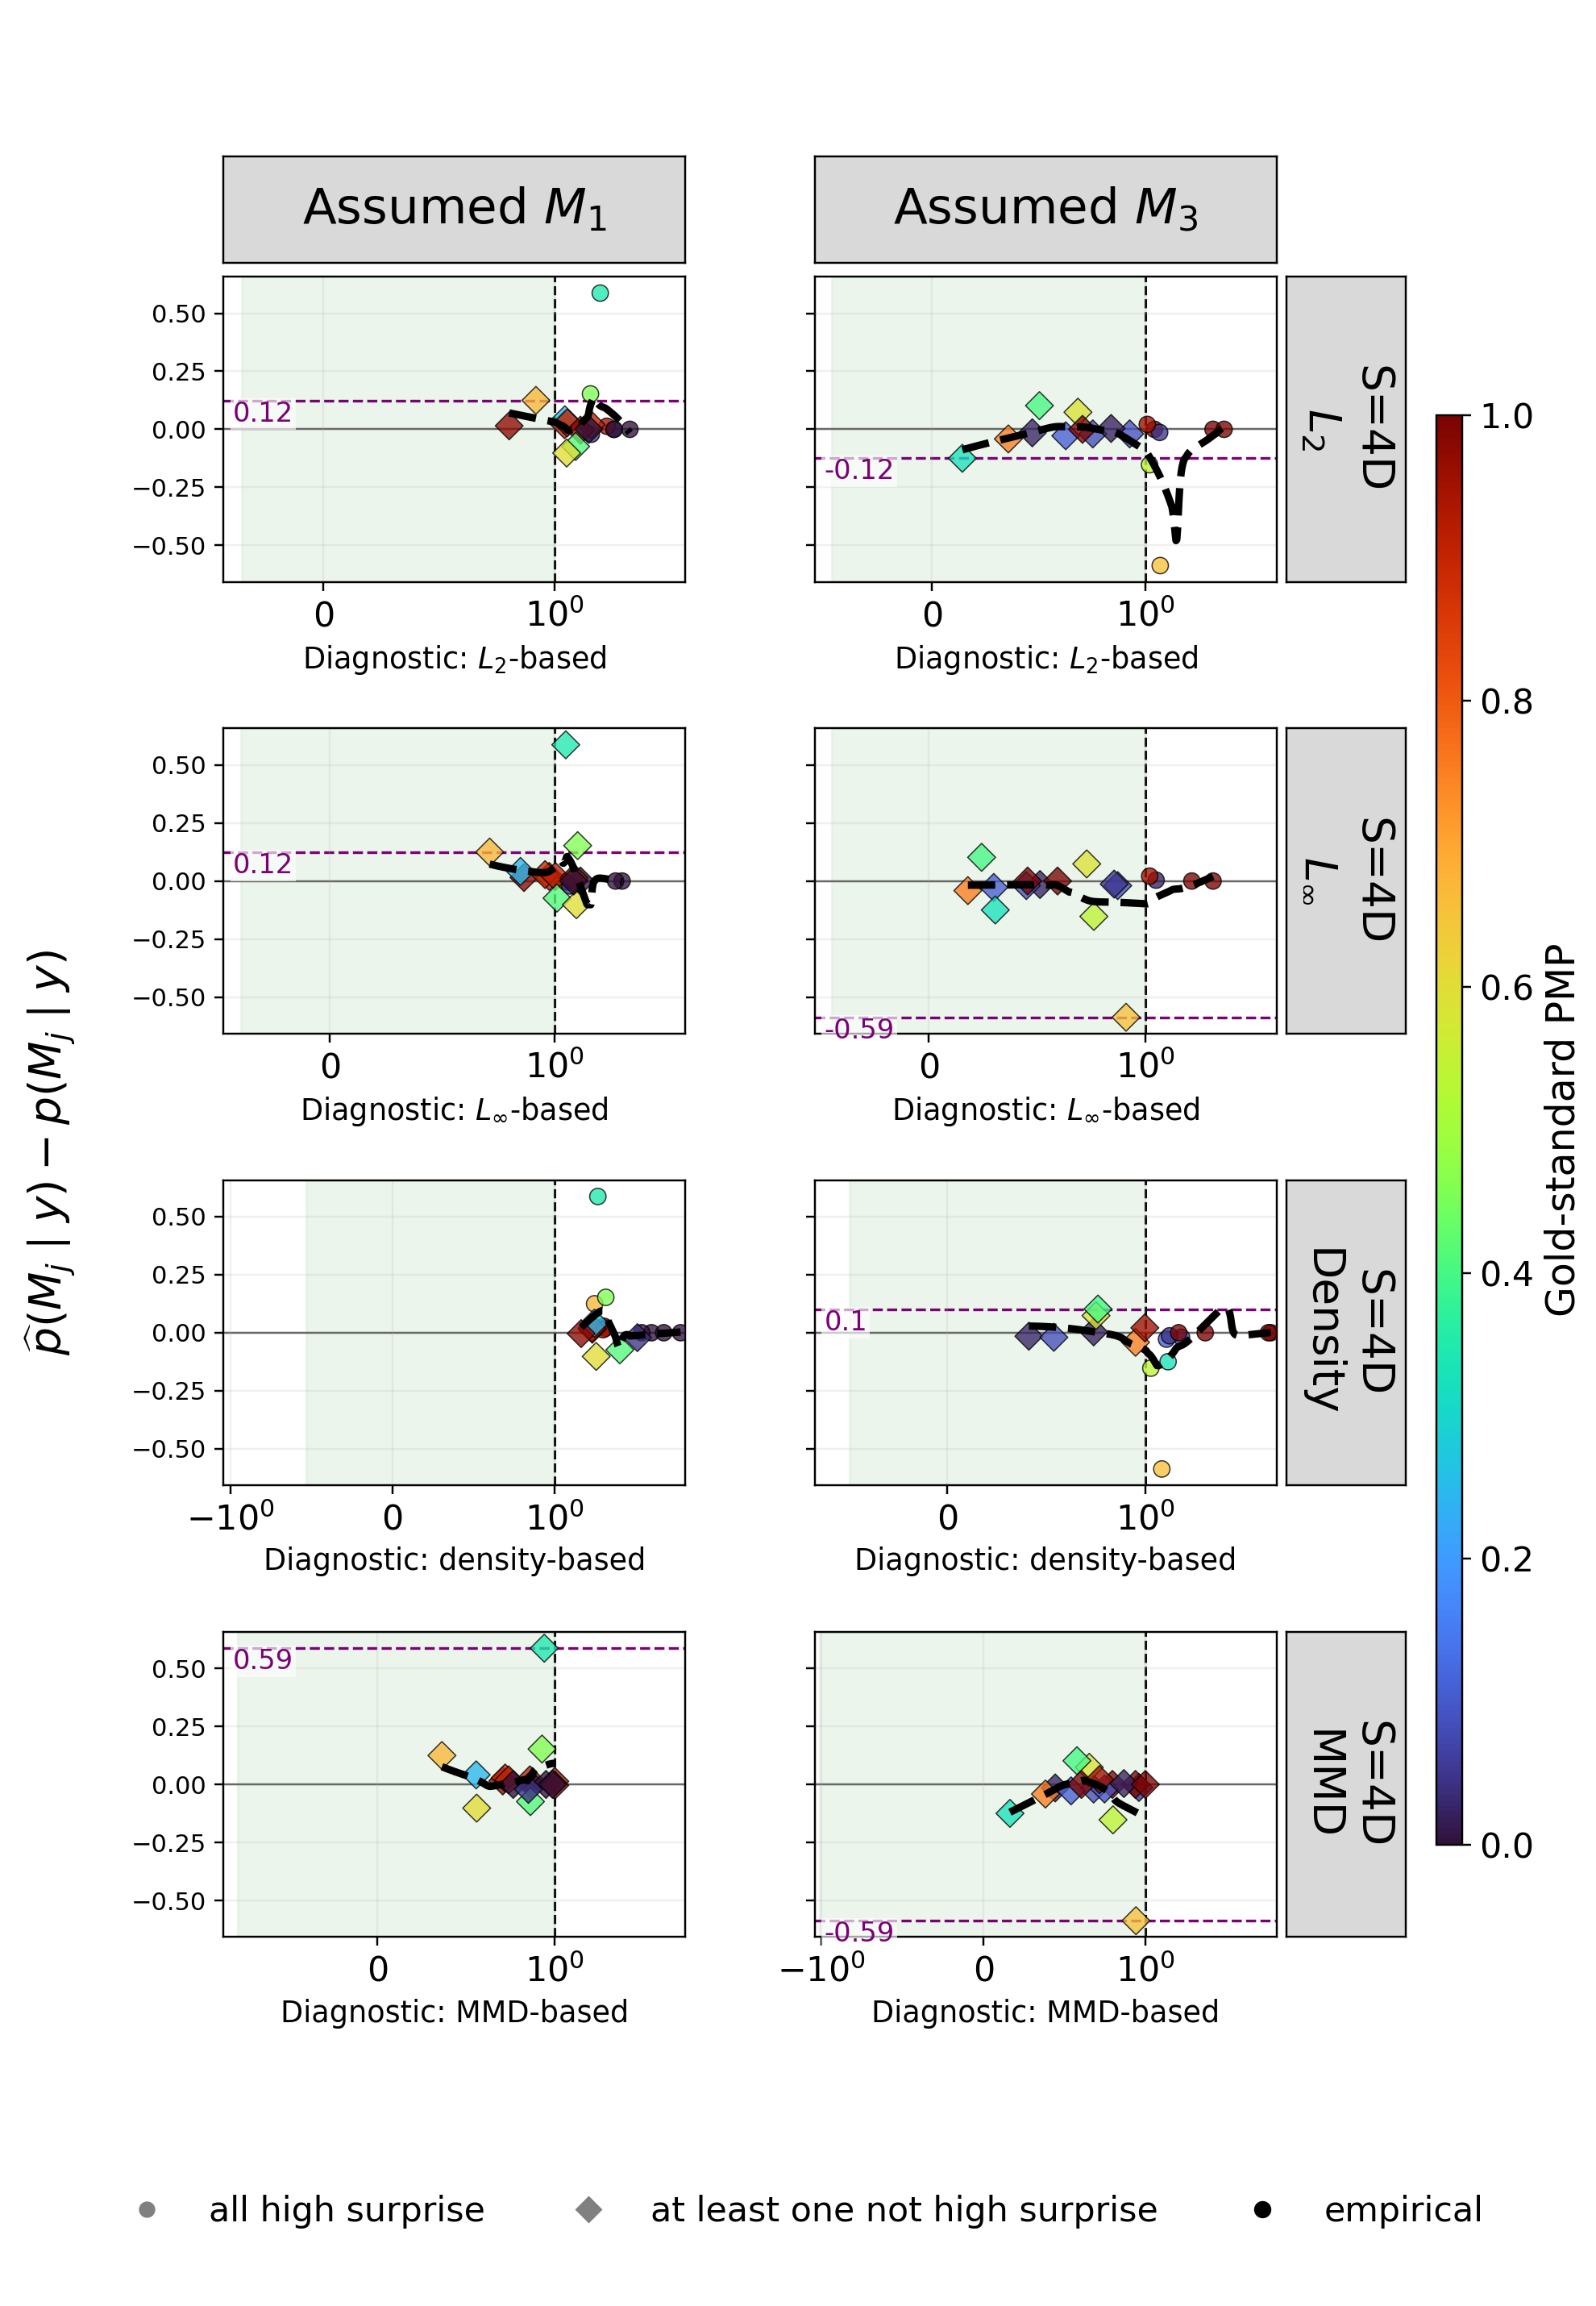

In [3]:
s4d_grid = generate_s4d_diagnostic_gold_pmp_grid(
    loss_variant=RERUN_VARIANT,
    output_root=OUTPUT_ROOT,
    xscale=XSCALE,
    yscale=YSCALE,
    gold_pmp_cmap='turbo',
    show_max_error=True,
)

display(Markdown('## Empirical PMP error: S=4D across four diagnostics'))
display(Image(filename=str(s4d_grid['png']), width=800))

## Empirical base-10 log marginal-likelihood error across four diagnostics

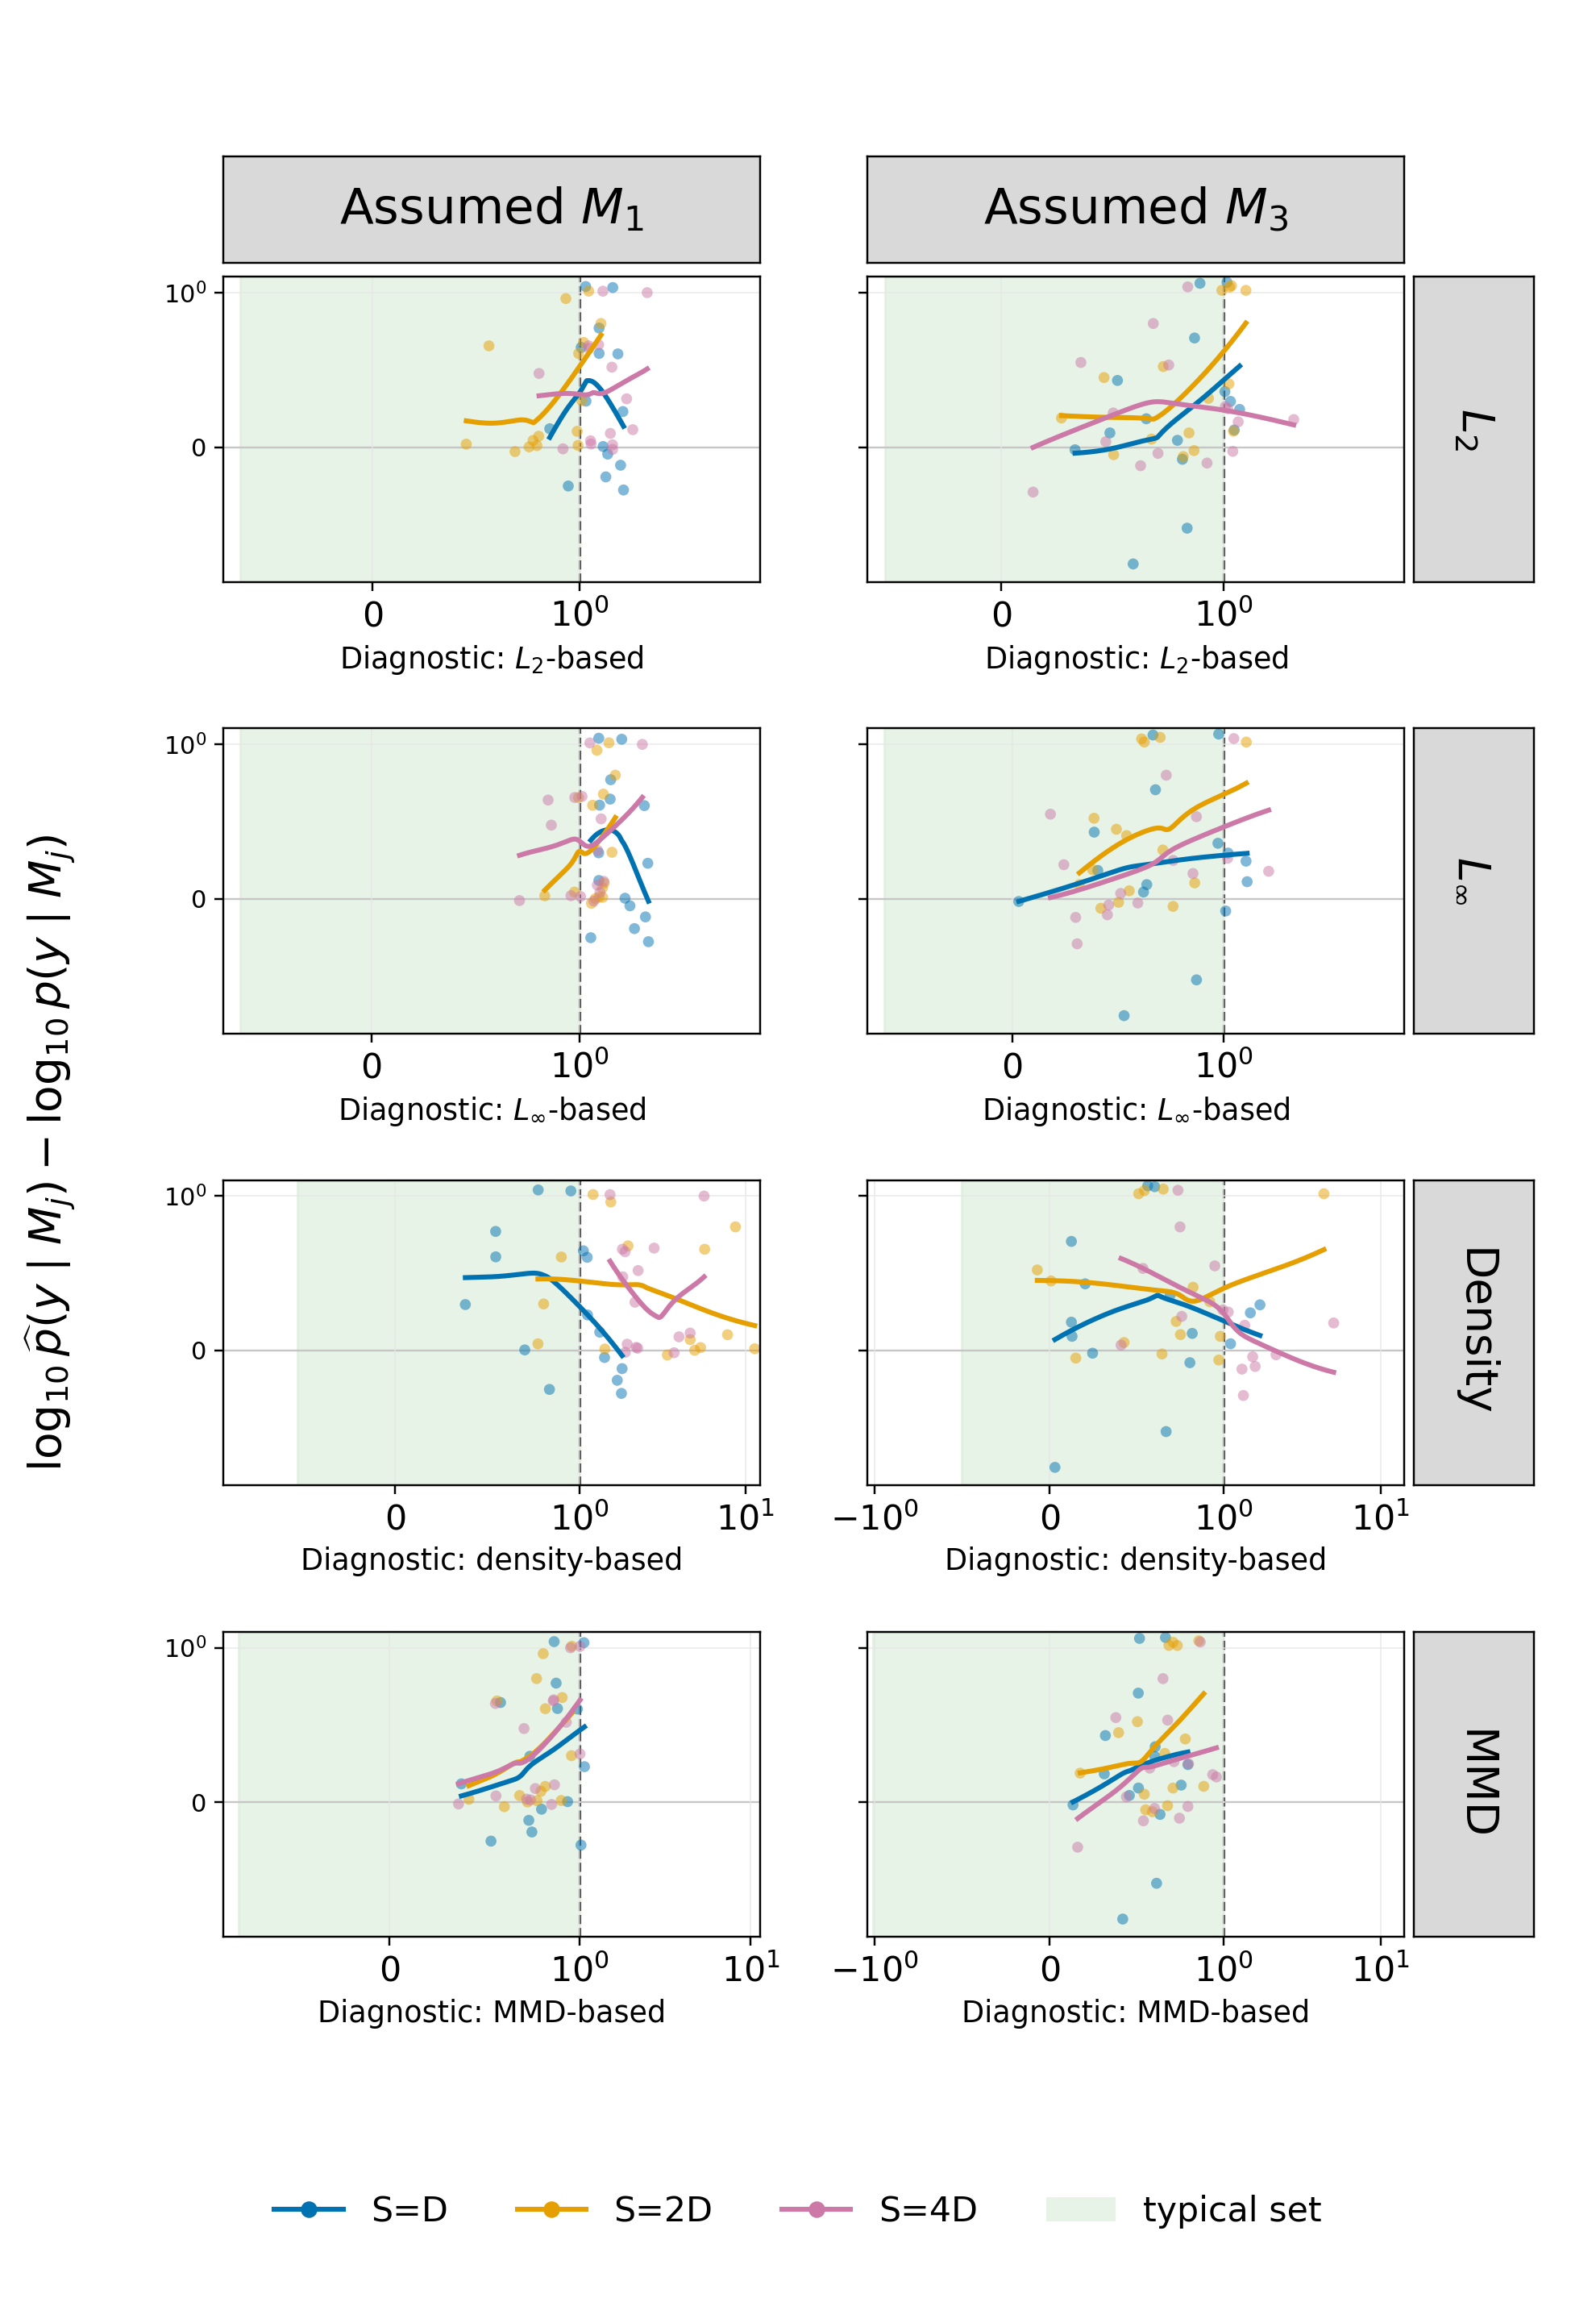

In [4]:
log10_logml_grid = generate_log10_logml_diagnostic_loess_grid(
    loss_variant=RERUN_VARIANT,
    output_root=OUTPUT_ROOT,
    xscale=XSCALE,
    yscale=YSCALE,
)

display(Markdown('## Empirical base-10 log marginal-likelihood error across four diagnostics'))
display(Image(filename=str(log10_logml_grid['png']), width=800))

## Empirical signed PMP error across four diagnostics

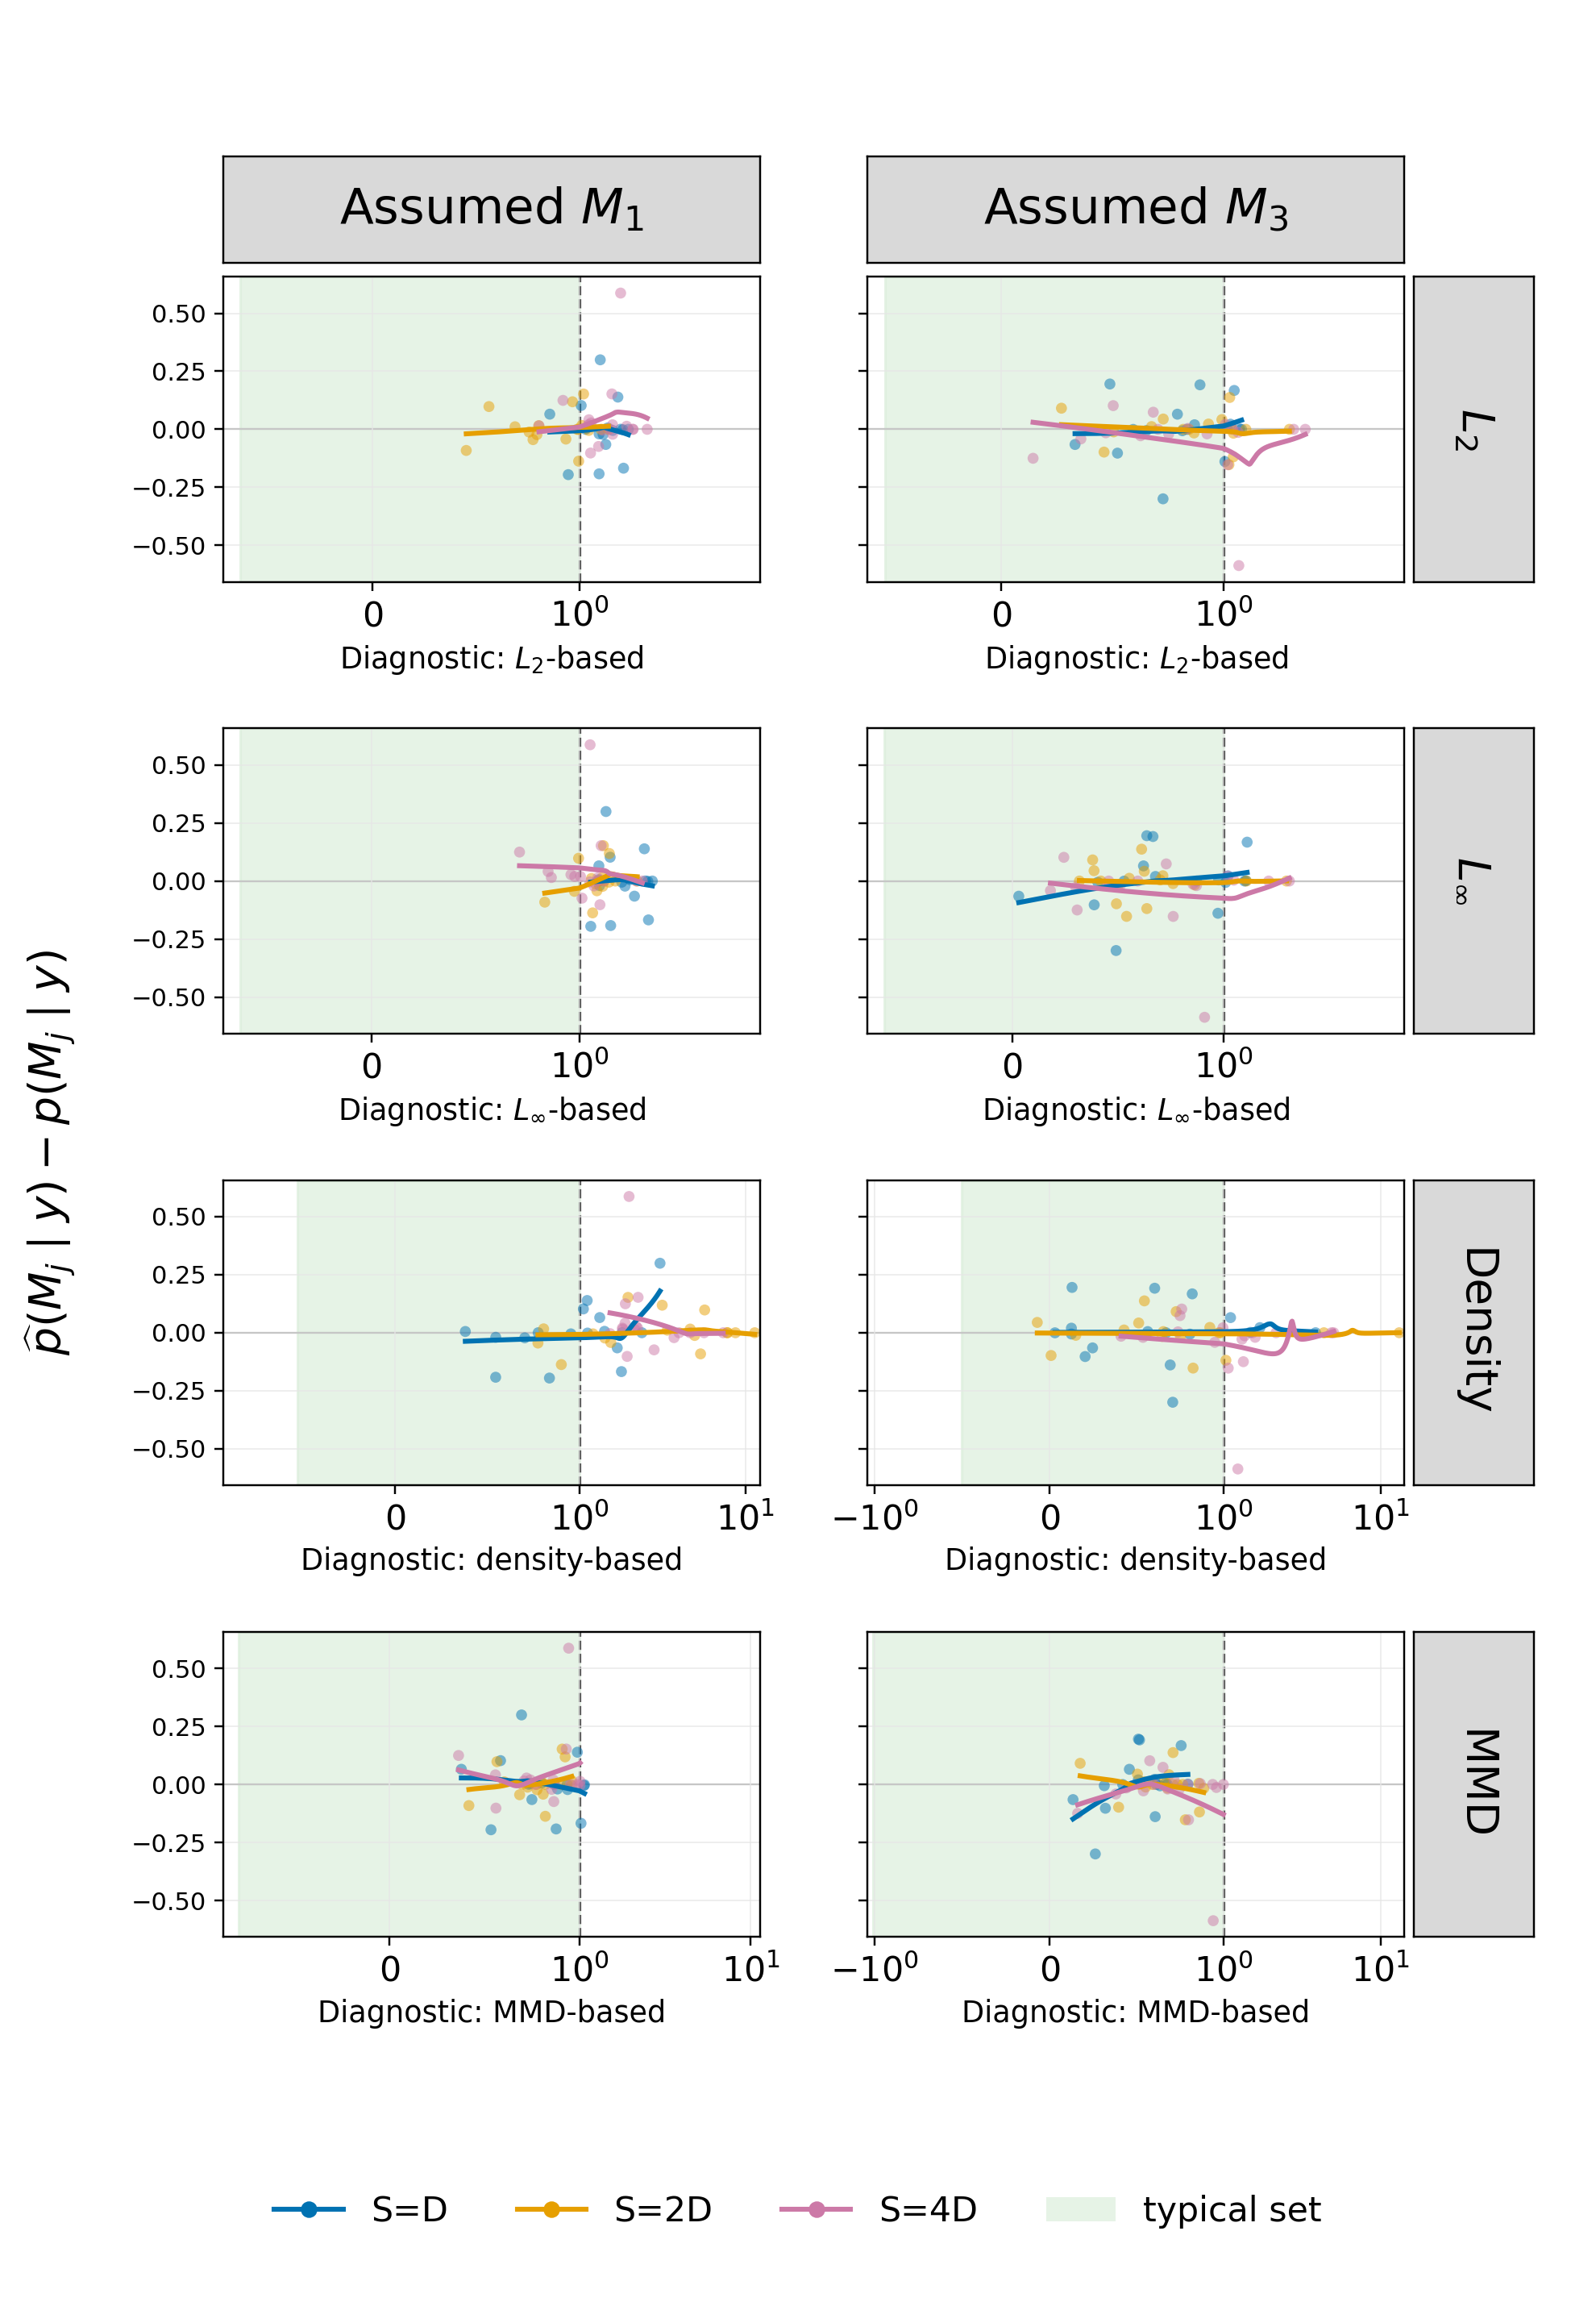

In [5]:
pmp_error_grid = generate_pmp_diagnostic_loess_grid(
    loss_variant=RERUN_VARIANT,
    output_root=OUTPUT_ROOT,
    xscale=XSCALE,
    yscale=YSCALE,
)

display(Markdown('## Empirical signed PMP error across four diagnostics'))
display(Image(filename=str(pmp_error_grid['png']), width=800))

## Empirical raw posterior MMD across four diagnostics

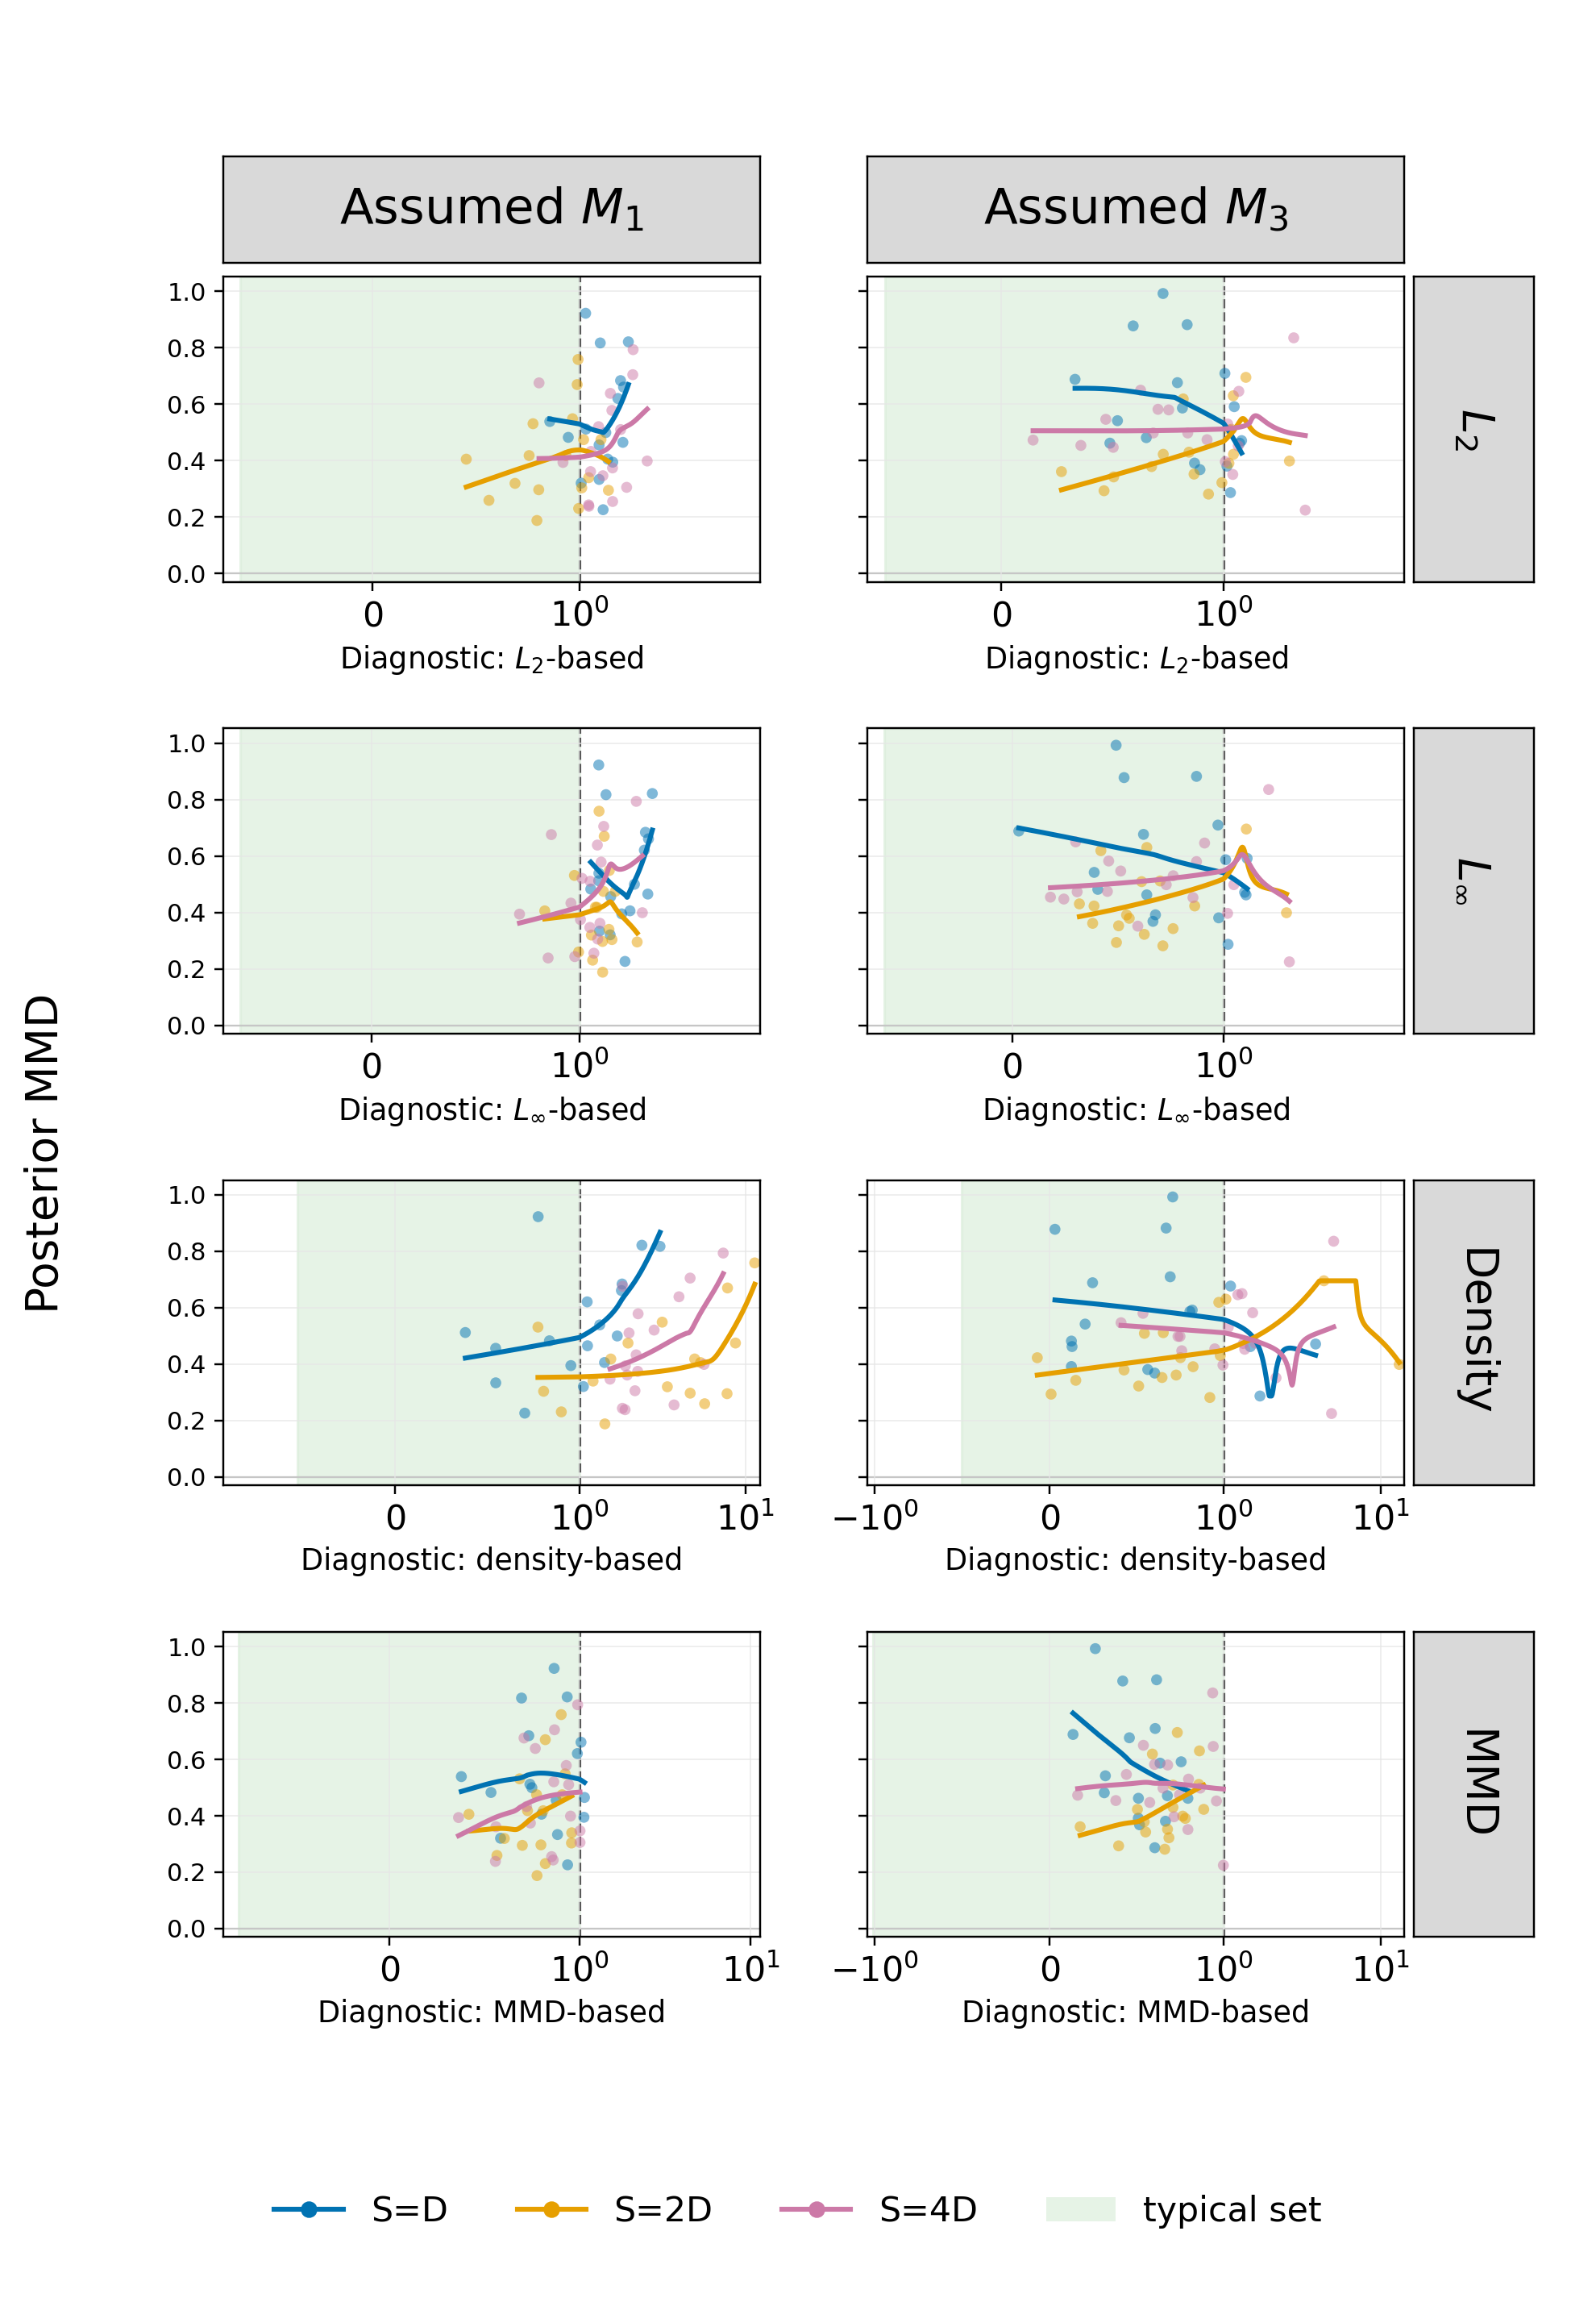

In [6]:
posterior_mmd_grid = generate_posterior_mmd_diagnostic_loess_grid(
    loss_variant=RERUN_VARIANT,
    output_root=OUTPUT_ROOT,
    xscale=XSCALE,
    yscale=YSCALE,
)

display(Markdown('## Empirical raw posterior MMD across four diagnostics'))
display(Image(filename=str(posterior_mmd_grid['png']), width=800))

In [7]:
# Regenerate every calibrated diagnostic figure from the current threshold file.
# This is plotting-only: it reuses cached diagnostics/posteriors and does not rerun training or MCMC.
calibrated_comparisons = run_calibrated_comparison_pipeline(
    metrics=DIAGNOSTICS,
    model_sets=MODEL_SETS,
    summary_specs=RERUN_SUMMARY_SPECS,
    output_root=CALIBRATED_OUTPUT_ROOT,
    xscale=XSCALE,
    yscale=YSCALE,
    normalize_metrics=NORMALIZE_METRICS,
    threshold_path=THRESHOLD_PATH,
)
calibrated_gold_pmp = {
    diagnostic: generate_calibrated_gold_pmp_lowess_grid(
        diagnostic,
        output_root=OVERLAY_OUTPUT_ROOT,
        threshold_path=THRESHOLD_PATH,
        summary_specs=RERUN_SUMMARY_SPECS,
        output_variant=RERUN_VARIANT,
        xscale=XSCALE,
        yscale=YSCALE,
        normalize_metrics=NORMALIZE_METRICS,
    )
    for diagnostic in DIAGNOSTICS
}
print(f'Generated {len(calibrated_comparisons)} calibrated comparisons')
print(f'Generated {len(calibrated_gold_pmp)} calibrated empirical facet grids')

Generated 8 calibrated comparisons
Generated 4 calibrated empirical facet grids
